# Construction Safety Monitor — YOLOv8 Training Notebook

**Task:** PPE compliance detection on construction sites  
**Model:** YOLOv8m (medium) fine-tuned on custom dataset  
**Classes:** `person`, `hard_hat`, `no_hard_hat`, `safety_vest`, `no_safety_vest`

---
### Runtime Setup
`T4 GPU`

## 1. Environment Setup

In [1]:
# Verify GPU is available
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout if result.returncode == 0 else 'No GPU found — change runtime to T4 GPU')

Wed Apr  1 09:13:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [12]:
# Install dependencies
!pip install pillow opencv-python-headless imagehash tqdm matplotlib pyyaml -q ultralytics roboflow albumentations matplotlib seaborn -q

import torch
print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
print(f'GPU             : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None"}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 83.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 136.7 MB/s eta 0:00:00
PyTorch version : 2.10.0+cu128
CUDA available  : False
GPU             : None


## 2. Dataset Download from Roboflow and Dataset Preperation

In [13]:
# ---------------------------------------------------------------
# Download  dataset from Roboflow
# ---------------------------------------------------------------
from roboflow import Roboflow


rf = Roboflow(api_key="cz4PZdDKF4ibHFXC1zhG")
project = rf.workspace("hashinifdo").project("construction-safety-gsnvb-amiuj")
version = project.version(3)
dataset = version.download("yolov8")


DATASET_PATH = dataset.location
print(f'Dataset downloaded to: {DATASET_PATH}')

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to construction-safety-3 in yolov8:: 100%|██████████| 9398/9398 [00:02<00:00, 3414.47it/s]


Dataset downloaded to: /content/construction-safety-3


In [14]:
# import required dependencies
import os
import cv2
import yaml
import shutil
import hashlib
import imagehash
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from pathlib import Path
from collections import Counter, defaultdict
from tqdm import tqdm


Classes: ['Hardhat', 'NO-Hardhat', 'NO-Safety Vest', 'Person', 'Safety Vest']
NC     : 5


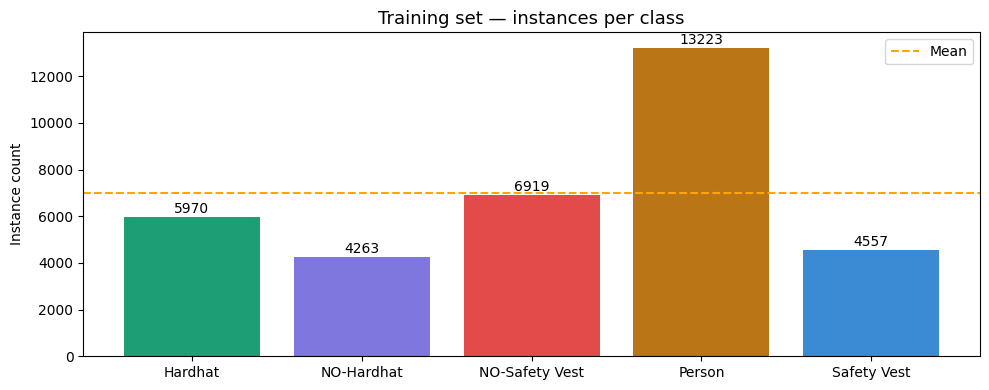

Saved: class_distribution.png


In [15]:
# Inspect dataset structure and class distribution
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Load data.yaml
yaml_path = Path(DATASET_PATH) / 'data.yaml'
with open(yaml_path) as f:
    data_cfg = yaml.safe_load(f)

print('Classes:', data_cfg['names'])
print('NC     :', data_cfg['nc'])

# Count instances per class across train split
train_labels = Path(DATASET_PATH) / 'train' / 'labels'
class_counts = Counter()

for label_file in train_labels.glob('*.txt'):
    with open(label_file) as f:
        for line in f:
            cls = int(line.strip().split()[0])
            class_counts[cls] += 1

names = data_cfg['names']
counts = [class_counts[i] for i in range(len(names))]

colors = ['#1D9E75','#7F77DD','#E24B4A','#BA7517','#3B8BD4']
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(names, counts, color=colors[:len(names)], edgecolor='none', linewidth=0)
ax.axhline(y=sum(counts)/len(counts), color='orange', linestyle='--', linewidth=1.5, label='Mean')
ax.set_title('Training set — instances per class', fontsize=13)
ax.set_ylabel('Instance count')
ax.legend()
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            str(count), ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print('Saved: class_distribution.png')

## 3. Dataset Cleaning and Preparation

Before training, the dataset was cleaned and standardized to improve label quality and training reliability.

The preprocessing pipeline performs the following steps:
- Removes corrupt images
- Removes exact duplicate images using MD5 hashing
- Removes images without label files
- Cleans YOLO label files by:
  - fixing class IDs stored as floats
  - clamping normalized box values to [0, 1]
  - removing invalid boxes
- Resizes images to 640×640
- Splits the cleaned dataset into:
  - Train: 70%
  - Validation: 20%
  - Test: 10%

This ensures that the final dataset is consistent, reproducible, and suitable for model training.

In [16]:
import os
import cv2
import random
import shutil
import hashlib
from PIL import Image
from tqdm import tqdm
from collections import Counter

# =========================
# CONFIG
# =========================
# Use the path returned by Roboflow (defined in Cell 5)
DATASET_PATH_TRAIN = os.path.join(DATASET_PATH, "train")   # FIX: was hardcoded
OUTPUT_PATH        = "/content/cleaned-construction-safety-dataset"  # FIX: absolute path

IMG_EXTS   = {".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"}  # FIX: case-sensitive set
TARGET_SIZE = (640, 640)

TRAIN_RATIO = 0.7
VAL_RATIO   = 0.2
TEST_RATIO  = 0.1

# =========================
# HELPERS
# =========================
def is_image(file):
    return os.path.splitext(file)[1] in IMG_EXTS  # FIX: removed .lower() — covered by set above

def get_label(img_file):
    return os.path.splitext(img_file)[0] + ".txt"

def verify_image(path):
    # FIX: use try/except with a fresh open; verify() closes the internal stream
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except Exception:
        return False

def resize_image(path):
    img = cv2.imread(path)
    if img is None:
        return
    resized = cv2.resize(img, TARGET_SIZE)
    cv2.imwrite(path, resized)

def clean_label(label_path):
    if not os.path.exists(label_path):
        return 0
    with open(label_path, "r") as f:
        lines = f.readlines()
    cleaned = []
    for line in lines:
        parts = line.strip().split()
        if len(parts) != 5:
            continue
        try:
            cls = int(float(parts[0]))      # FIX: int(float()) handles "0.0" in labels
            x   = min(max(float(parts[1]), 0.0), 1.0)
            y   = min(max(float(parts[2]), 0.0), 1.0)
            w   = min(max(float(parts[3]), 0.0), 1.0)
            h   = min(max(float(parts[4]), 0.0), 1.0)
            if w <= 0 or h <= 0:
                continue
            cleaned.append(f"{cls} {x:.6f} {y:.6f} {w:.6f} {h:.6f}\n")
        except Exception:
            continue
    with open(label_path, "w") as f:
        f.writelines(cleaned)
    return len(cleaned)

def get_hash(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

# =========================
# CLEANING
# =========================
def clean_dataset():
    image_dir = os.path.join(DATASET_PATH_TRAIN, "images")
    label_dir = os.path.join(DATASET_PATH_TRAIN, "labels")

    cleaned_data  = []
    seen_hashes   = set()
    stats         = Counter()

    for img_file in tqdm(os.listdir(image_dir), desc="Cleaning"):
        if not is_image(img_file):
            continue

        img_path   = os.path.join(image_dir, img_file)
        label_path = os.path.join(label_dir, get_label(img_file))

        # 1. Remove corrupt images
        if not verify_image(img_path):
            stats["corrupt_removed"] += 1
            continue

        # 2. Remove exact duplicates (MD5 hash)
        h = get_hash(img_path)
        if h in seen_hashes:
            stats["duplicate_removed"] += 1
            continue
        seen_hashes.add(h)

        # 3. Remove images with no label file
        if not os.path.exists(label_path):
            stats["no_label_removed"] += 1
            continue

        # 4. Clean & validate label content
        valid_boxes = clean_label(label_path)
        if valid_boxes == 0:
            stats["empty_label_removed"] += 1
            continue

        # 5. Resize to training resolution
        resize_image(img_path)

        cleaned_data.append((img_path, label_path))
        stats["kept"] += 1

    print("\nCleaning Summary:", dict(stats))
    return cleaned_data

# =========================
# SPLITTING
# =========================
def split_dataset(cleaned_data):
    random.shuffle(cleaned_data)
    total     = len(cleaned_data)
    train_end = int(total * TRAIN_RATIO)
    val_end   = train_end + int(total * VAL_RATIO)

    splits = {
        "train": cleaned_data[:train_end],
        "valid": cleaned_data[train_end:val_end],
        "test" : cleaned_data[val_end:],
    }

    for split_name, items in splits.items():
        img_out = os.path.join(OUTPUT_PATH, split_name, "images")
        lbl_out = os.path.join(OUTPUT_PATH, split_name, "labels")
        os.makedirs(img_out, exist_ok=True)
        os.makedirs(lbl_out, exist_ok=True)
        for img_path, lbl_path in items:
            shutil.copy(img_path, img_out)
            shutil.copy(lbl_path, lbl_out)

    print("\nDataset split:")
    for split_name, items in splits.items():
        print(f"  {split_name}: {len(items)} images")

# =========================
# RUN PIPELINE
# =========================
data = clean_dataset()
split_dataset(data)

# FIX: expose OUTPUT_PATH as DATASET_PATH_CLEAN so Cell 11 can use it
DATASET_PATH_CLEAN = OUTPUT_PATH
print(f"\nCleaned dataset ready at: {DATASET_PATH_CLEAN}")


Cleaning: 100%|██████████| 4696/4696 [00:37<00:00, 123.79it/s]



Cleaning Summary: {'empty_label_removed': 98, 'kept': 4598}

Dataset split:
  train: 3218 images
  valid: 919 images
  test: 461 images

Cleaned dataset ready at: /content/cleaned-construction-safety-dataset


Classes: ['Hardhat', 'NO-Hardhat', 'NO-Safety Vest', 'Person', 'Safety Vest']
NC     : 5

 Instance counts:
Hardhat: 4208
NO-Hardhat: 2995
NO-Safety Vest: 4874
Person: 9260
Safety Vest: 3215

 Image counts:
Hardhat: 1803
NO-Hardhat: 1509
NO-Safety Vest: 2175
Person: 2860
Safety Vest: 1440


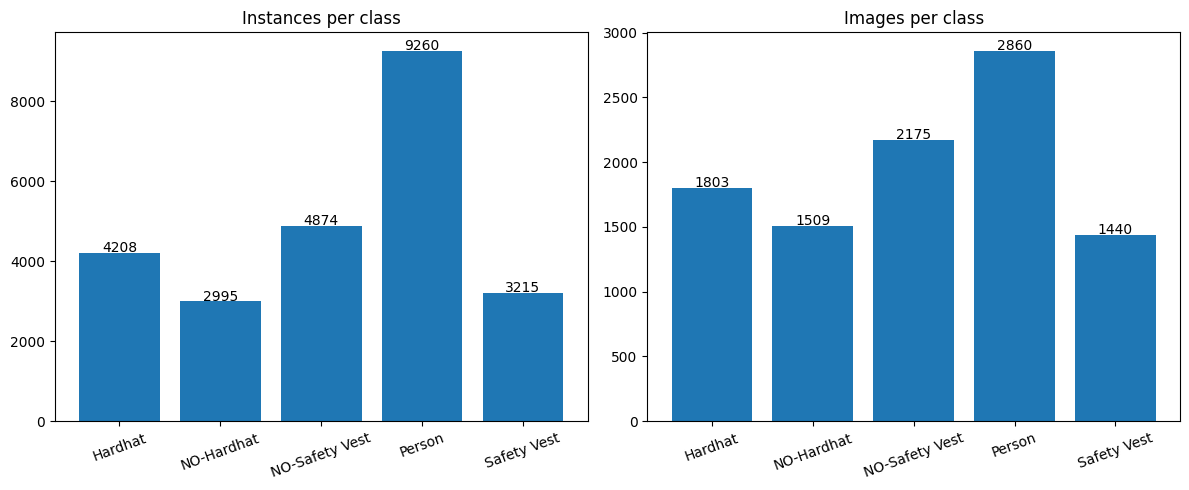

In [17]:
# Visualizations of images and instances per class

from pathlib import Path
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import yaml

# =========================
# LOAD CONFIG
# =========================
yaml_path = Path(DATASET_PATH) / 'data.yaml'
with open(yaml_path) as f:
    data_cfg = yaml.safe_load(f)

names = data_cfg['names']
num_classes = data_cfg['nc']

print('Classes:', names)
print('NC     :', num_classes)

# =========================
# PATH
# =========================
train_labels = Path(OUTPUT_PATH) / 'train' / 'labels'

# =========================
# COUNT INSTANCES + IMAGES
# =========================
instance_counts = Counter()
image_counts = Counter()

for label_file in train_labels.glob('*.txt'):
    classes_in_image = set()

    with open(label_file) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                cls = int(float(parts[0]))
                instance_counts[cls] += 1
                classes_in_image.add(cls)

    # count image presence per class
    for cls in classes_in_image:
        image_counts[cls] += 1

# =========================
# PRINT RESULTS
# =========================
print("\n Instance counts:")
for i in range(num_classes):
    print(f"{names[i]}: {instance_counts[i]}")

print("\n Image counts:")
for i in range(num_classes):
    print(f"{names[i]}: {image_counts[i]}")

# =========================
# PLOT BOTH
# =========================
instance_values = [instance_counts[i] for i in range(num_classes)]
image_values = [image_counts[i] for i in range(num_classes)]

x = range(num_classes)

plt.figure(figsize=(12, 5))

# Instances
plt.subplot(1, 2, 1)
bars = plt.bar(names, instance_values)
plt.title("Instances per class")
plt.xticks(rotation=20)

for bar, v in zip(bars, instance_values):
    plt.text(bar.get_x() + bar.get_width()/2, v + 20, str(v), ha='center')

# Images
plt.subplot(1, 2, 2)
bars = plt.bar(names, image_values)
plt.title("Images per class")
plt.xticks(rotation=20)

for bar, v in zip(bars, image_values):
    plt.text(bar.get_x() + bar.get_width()/2, v + 5, str(v), ha='center')

plt.tight_layout()
plt.show()

Dataset Balancing

##3. Dataset Balancing with Sampling and Augmentations

To improve model performance and ensure fair learning across all classes, a controlled dataset balancing strategy was applied. The original dataset exhibited class imbalance, with the `person` class significantly dominating, while critical safety violation classes such as `no_hard_hat` and `safety_vest` were underrepresented.

### Dataset balancing is needed for

- **Prevents bias toward dominant classes**  
  Models trained on imbalanced data tend to over-predict frequent classes like `person`.

- **Improves detection of safety violations**  
  Rare but critical classes such as `no_hard_hat` and `no_safety_vest` must be well learned for accurate compliance monitoring.

- **Enhances generalization**  
  Balanced data improves robustness across different real-world scenarios.

- **Supports stable training**  
  Reduces skewed gradients and improves convergence during training.

---

### Balancing strategy

A two-stage approach was used:

### 1. Controlled Undersampling (Person Class Reduction)

The dominant `person` class was reduced through:

- **Removal of person-only images**
- **Removal of person-dominant images**
  - Images with high person ratio (>50–60%) were selectively removed
  - Ensured minority classes were not negatively affected
- Safety checks were applied to prevent dropping below minimum thresholds for other classes

This step reduces dataset bias while preserving useful information.

---

### 2. Targeted Augmentation (Minority Class Expansion)

Augmentation was applied selectively to underrepresented classes:

- Target classes:
  - `no_hard_hat`
  - `safety_vest`

- Each image was augmented multiple times (with limits to avoid duplication)

- Augmentation techniques used:
  - Horizontal flipping
  - Affine transformations (scale, rotation, translation, shear)
  - Perspective distortion
  - Brightness and contrast adjustment
  - Hue and saturation variation
  - CLAHE (contrast enhancement)
  - Gaussian blur

- Bounding boxes were carefully handled:
  - Clipped to valid ranges
  - Filtered using minimum visibility thresholds

---

### 3. Controlled Acceptance Mechanism

Each augmented sample was validated before being added:

- Prevented exceeding class target ranges
- Limited excessive growth of dominant classes
- Ensured dataset remains within a balanced range (~4000–5000 instances per class)

---

### Final Outcome

- Dataset classes were balanced within a target range
- Improved representation of safety violation classes
- Reduced dominance of `person` class
- Maintained dataset diversity without overfitting

This balanced dataset significantly improves the model's ability to detect both compliant and non-compliant workers effectively.


Original training stats
Hardhat         instances=4208   images=1803
NO-Hardhat      instances=2995   images=1509
NO-Safety Vest  instances=4874   images=2175
Person          instances=9260   images=2860
Safety Vest     instances=3215   images=1440


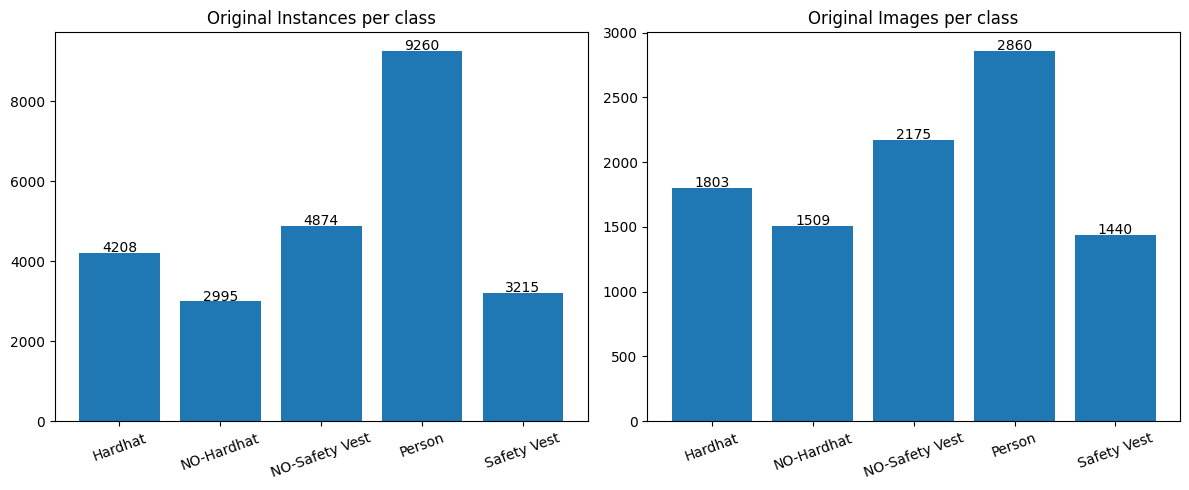


Removed Person-only images: 88
Removed Person-dominant images: 0

After Person undersampling
Hardhat         instances=4208   images=1803
NO-Hardhat      instances=2995   images=1509
NO-Safety Vest  instances=4874   images=2175
Person          instances=9097   images=2772
Safety Vest     instances=3215   images=1440


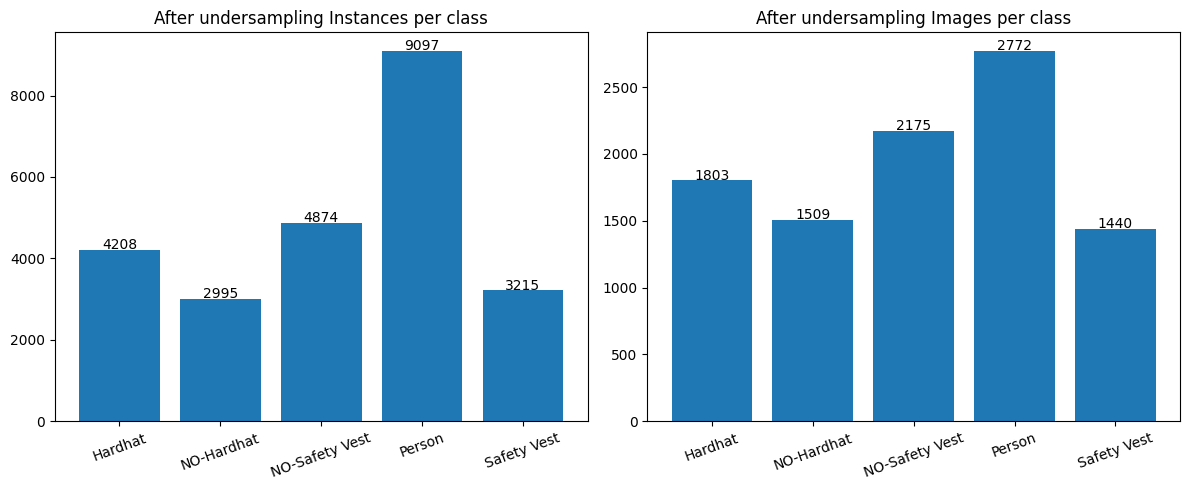


Stopped because no more safe augmentation candidates remained.

Final balanced training stats
Hardhat         instances=4208   images=1803
NO-Hardhat      instances=2995   images=1509
NO-Safety Vest  instances=4874   images=2175
Person          instances=9097   images=2772
Safety Vest     instances=3215   images=1440


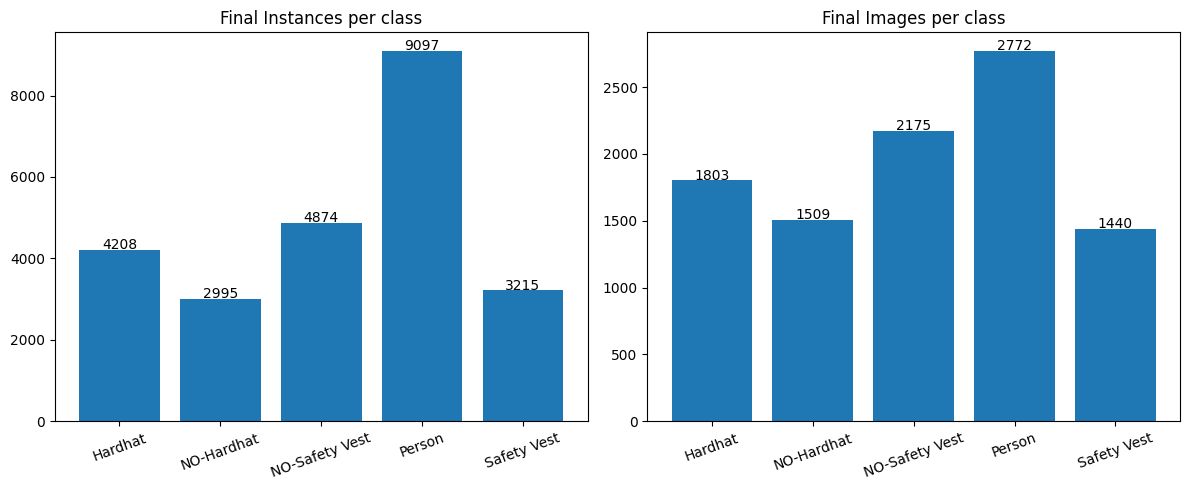


Balanced dataset saved to: /content/balanced-4000-5000-dataset


In [18]:
# ============================================================
# BALANCE DETECTION DATASET TO ~4000-5000 INSTANCES
# - Reduce Person to about 4800-5000
# - Increase NO-Hardhat and Safety Vest to about 4300-4500
# - Keep Hardhat and NO-Safety Vest as they are
# - Safe Albumentations + safe bbox handling
# ============================================================

from pathlib import Path
from collections import Counter, defaultdict
import shutil
import random
import cv2
import numpy as np
import albumentations as A
import matplotlib.pyplot as plt

# =========================
# PATHS
# =========================
DATASET_ROOT  = Path("/content/cleaned-construction-safety-dataset")
TRAIN_IMAGES  = DATASET_ROOT / "train" / "images"
TRAIN_LABELS  = DATASET_ROOT / "train" / "labels"

VALID_IMAGES  = DATASET_ROOT / "valid" / "images"
VALID_LABELS  = DATASET_ROOT / "valid" / "labels"

TEST_IMAGES   = DATASET_ROOT / "test" / "images"
TEST_LABELS   = DATASET_ROOT / "test" / "labels"

OUTPUT_ROOT   = Path("/content/balanced-4000-5000-dataset")

# =========================
# CONFIG
# =========================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

CLASS_NAMES = {
    0: "Hardhat",
    1: "NO-Hardhat",
    2: "NO-Safety Vest",
    3: "Person",
    4: "Safety Vest",
}

PERSON_ID = 3
ALL_CLASS_IDS = [0, 1, 2, 3, 4]
AUGMENT_TARGET_IDS = [1, 4]   # NO-Hardhat and Safety Vest

# final desired band
TARGET_MIN = 4000
TARGET_MAX = 5000

# class-specific desired targets
TARGET_COUNTS = {
    0: 4200,   # Hardhat
    1: 4400,   # NO-Hardhat
    2: 4700,   # NO-Safety Vest
    3: 4900,   # Person
    4: 4400,   # Safety Vest
}

TARGET_BUFFER = 80
MAX_AUG_PER_IMAGE = 4

# =========================
# SAFE ALBUMENTATIONS
# =========================
augment = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Affine(
        scale=(0.95, 1.05),
        translate_percent={"x": (-0.03, 0.03), "y": (-0.03, 0.03)},
        rotate=(-8, 8),
        shear=(-3, 3),
        fit_output=False,
        border_mode=cv2.BORDER_REFLECT_101,
        p=0.45
    ),
    A.RandomBrightnessContrast(
        brightness_limit=0.18,
        contrast_limit=0.18,
        p=0.40
    ),
    A.HueSaturationValue(
        hue_shift_limit=8,
        sat_shift_limit=10,
        val_shift_limit=10,
        p=0.25
    ),
    A.CLAHE(
        clip_limit=2.5,
        tile_grid_size=(8, 8),
        p=0.18
    ),
    A.GaussianBlur(
        blur_limit=(3, 5),
        p=0.08
    ),
], bbox_params=A.BboxParams(
    format="yolo",
    label_fields=["class_labels"],
    min_visibility=0.30
))

# =========================
# HELPERS
# =========================
def ensure_dir(path: Path):
    path.mkdir(parents=True, exist_ok=True)

def reset_output():
    if OUTPUT_ROOT.exists():
        shutil.rmtree(OUTPUT_ROOT)
    for split in ["train", "valid", "test"]:
        ensure_dir(OUTPUT_ROOT / split / "images")
        ensure_dir(OUTPUT_ROOT / split / "labels")

def copy_split(src_img_dir: Path, src_lbl_dir: Path, dst_img_dir: Path, dst_lbl_dir: Path):
    ensure_dir(dst_img_dir)
    ensure_dir(dst_lbl_dir)

    if src_img_dir.exists():
        for img in src_img_dir.iterdir():
            if img.is_file():
                shutil.copy2(img, dst_img_dir / img.name)

    if src_lbl_dir.exists():
        for lbl in src_lbl_dir.glob("*.txt"):
            shutil.copy2(lbl, dst_lbl_dir / lbl.name)

def find_image_for_label(stem: str, image_dir: Path):
    for ext in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]:
        p = image_dir / f"{stem}{ext}"
        if p.exists():
            return p
    return None

def clip_yolo_box(box, eps=1e-6):
    x, y, w, h = map(float, box)

    x = min(max(x, 0.0), 1.0)
    y = min(max(y, 0.0), 1.0)
    w = min(max(w, eps), 1.0)
    h = min(max(h, eps), 1.0)

    max_w = 2 * min(x, 1 - x) if 0 < x < 1 else 1.0
    max_h = 2 * min(y, 1 - y) if 0 < y < 1 else 1.0

    w = min(w, max(max_w, eps))
    h = min(h, max(max_h, eps))

    w = max(w, eps)
    h = max(h, eps)

    return [x, y, w, h]

def clean_yolo_boxes(class_ids, bboxes, eps=1e-6):
    clean_classes = []
    clean_boxes = []

    for cls, box in zip(class_ids, bboxes):
        try:
            x, y, w, h = map(float, box)
        except:
            continue

        if w <= 0 or h <= 0:
            continue

        box = clip_yolo_box([x, y, w, h], eps=eps)
        x, y, w, h = box

        x_min = x - w / 2
        y_min = y - h / 2
        x_max = x + w / 2
        y_max = y + h / 2

        tol = 1e-5
        if x_min < -tol or y_min < -tol or x_max > 1 + tol or y_max > 1 + tol:
            continue

        clean_classes.append(int(cls))
        clean_boxes.append([x, y, w, h])

    return clean_classes, clean_boxes

def read_yolo_label(label_path: Path):
    class_ids = []
    bboxes = []

    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            try:
                cls = int(float(parts[0]))
                x, y, w, h = map(float, parts[1:5])
                class_ids.append(cls)
                bboxes.append([x, y, w, h])
            except:
                continue

    return clean_yolo_boxes(class_ids, bboxes)

def write_yolo_label(label_path: Path, class_ids, bboxes):
    with open(label_path, "w") as f:
        for cls, box in zip(class_ids, bboxes):
            x, y, w, h = box
            f.write(f"{int(cls)} {x:.6f} {y:.6f} {w:.6f} {h:.6f}\n")

def get_records(image_dir: Path, label_dir: Path):
    records = []

    for lbl_path in sorted(label_dir.glob("*.txt")):
        stem = lbl_path.stem
        img_path = find_image_for_label(stem, image_dir)
        if img_path is None:
            continue

        class_ids, bboxes = read_yolo_label(lbl_path)
        if not class_ids:
            continue

        counts = Counter(class_ids)
        total_objs = sum(counts.values())
        person_count = counts.get(PERSON_ID, 0)
        non_person_count = total_objs - person_count

        records.append({
            "stem": stem,
            "img_path": img_path,
            "lbl_path": lbl_path,
            "class_ids": class_ids,
            "bboxes": bboxes,
            "counts": counts,
            "class_set": set(counts.keys()),
            "person_count": person_count,
            "non_person_count": non_person_count,
            "only_person": set(counts.keys()) == {PERSON_ID},
            "has_other_classes": len(set(counts.keys()) - {PERSON_ID}) > 0,
        })

    return records

def summarize_records(records):
    instance_counts = Counter()
    image_counts = Counter()

    for r in records:
        instance_counts.update(r["counts"])
        for cid in r["class_set"]:
            image_counts[cid] += 1

    return instance_counts, image_counts

def count_dir_stats(label_dir: Path):
    instance_counts = Counter()
    image_counts = Counter()

    for lbl_file in label_dir.glob("*.txt"):
        classes_in_image = set()
        with open(lbl_file, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    try:
                        cls = int(float(parts[0]))
                        instance_counts[cls] += 1
                        classes_in_image.add(cls)
                    except:
                        pass
        for cls in classes_in_image:
            image_counts[cls] += 1

    return instance_counts, image_counts

def print_stats(title, instance_counts, image_counts):
    print(f"\n{title}")
    for cid in ALL_CLASS_IDS:
        print(
            f"{CLASS_NAMES[cid]:<15} "
            f"instances={instance_counts[cid]:<6} "
            f"images={image_counts[cid]}"
        )

def plot_stats(instance_counts, image_counts, title_prefix=""):
    names = [CLASS_NAMES[cid] for cid in ALL_CLASS_IDS]
    inst_values = [instance_counts[cid] for cid in ALL_CLASS_IDS]
    img_values = [image_counts[cid] for cid in ALL_CLASS_IDS]

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    bars = plt.bar(names, inst_values)
    plt.title(f"{title_prefix} Instances per class")
    plt.xticks(rotation=20)
    for b, v in zip(bars, inst_values):
        plt.text(b.get_x() + b.get_width()/2, v + 20, str(v), ha="center")

    plt.subplot(1, 2, 2)
    bars = plt.bar(names, img_values)
    plt.title(f"{title_prefix} Images per class")
    plt.xticks(rotation=20)
    for b, v in zip(bars, img_values):
        plt.text(b.get_x() + b.get_width()/2, v + 5, str(v), ha="center")

    plt.tight_layout()
    plt.show()

def save_record(record, out_img_dir: Path, out_lbl_dir: Path):
    shutil.copy2(record["img_path"], out_img_dir / record["img_path"].name)
    shutil.copy2(record["lbl_path"], out_lbl_dir / record["lbl_path"].name)

def remove_saved_sample(base_name: str):
    img = OUT_TRAIN_IMAGES / f"{base_name}.jpg"
    lbl = OUT_TRAIN_LABELS / f"{base_name}.txt"
    if img.exists():
        img.unlink()
    if lbl.exists():
        lbl.unlink()

def needs_more(cid, current_counts):
    return current_counts[cid] < TARGET_COUNTS[cid] - TARGET_BUFFER

def is_safe_person_removal(record, current_counts):
    # remove whole image only if it does not damage rare classes too much
    projected = current_counts.copy()
    projected.subtract(record["counts"])

    # do not let other classes go below lower band
    for cid in [0, 1, 2, 4]:
        if projected[cid] < TARGET_MIN - TARGET_BUFFER:
            return False

    # person should still remain >= lower band after final removals
    if projected[PERSON_ID] < TARGET_MIN - TARGET_BUFFER:
        return False

    return True

def save_augmented_sample(record, suffix):
    image = cv2.imread(str(record["img_path"]))
    if image is None:
        return None, None

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    class_ids, bboxes = clean_yolo_boxes(record["class_ids"], record["bboxes"])
    if len(bboxes) == 0:
        return None, None

    try:
        transformed = augment(
            image=image,
            bboxes=bboxes,
            class_labels=class_ids
        )
    except ValueError:
        return None, None

    aug_img = transformed["image"]
    aug_boxes = transformed["bboxes"]
    aug_classes = transformed["class_labels"]

    if len(aug_boxes) == 0:
        return None, None

    aug_classes, aug_boxes = clean_yolo_boxes(aug_classes, aug_boxes)
    if len(aug_boxes) == 0:
        return None, None

    base_name = f"{record['stem']}_{suffix}"
    out_img_path = OUT_TRAIN_IMAGES / f"{base_name}.jpg"
    out_lbl_path = OUT_TRAIN_LABELS / f"{base_name}.txt"

    cv2.imwrite(str(out_img_path), cv2.cvtColor(aug_img, cv2.COLOR_RGB2BGR))
    write_yolo_label(out_lbl_path, aug_classes, aug_boxes)

    return Counter(aug_classes), set(aug_classes)

# =========================
# STEP 1: RESET OUTPUT
# =========================
reset_output()

copy_split(
    VALID_IMAGES, VALID_LABELS,
    OUTPUT_ROOT / "valid" / "images",
    OUTPUT_ROOT / "valid" / "labels"
)
copy_split(
    TEST_IMAGES, TEST_LABELS,
    OUTPUT_ROOT / "test" / "images",
    OUTPUT_ROOT / "test" / "labels"
)

yaml_file = DATASET_ROOT / "data.yaml"
if yaml_file.exists():
    shutil.copy2(yaml_file, OUTPUT_ROOT / "data.yaml")

# =========================
# STEP 2: LOAD TRAIN SET
# =========================
records = get_records(TRAIN_IMAGES, TRAIN_LABELS)
orig_instance_counts, orig_image_counts = summarize_records(records)
print_stats("Original training stats", orig_instance_counts, orig_image_counts)
plot_stats(orig_instance_counts, orig_image_counts, "Original")

# =========================
# STEP 3: PERSON UNDERSAMPLING
# Pass A: remove Person-only images
# Pass B: remove Person-dominant images carefully
# =========================
kept_by_stem = {r["stem"]: r for r in records}
current_counts = orig_instance_counts.copy()

# Pass A: person-only first
person_only = [r for r in records if r["only_person"] and r["person_count"] > 0]
person_only.sort(key=lambda r: r["person_count"], reverse=True)

removed_A = 0
for r in person_only:
    if current_counts[PERSON_ID] <= TARGET_COUNTS[PERSON_ID] + TARGET_BUFFER:
        break

    projected_person = current_counts[PERSON_ID] - r["person_count"]
    if projected_person < TARGET_COUNTS[PERSON_ID] - TARGET_BUFFER:
        continue

    kept_by_stem.pop(r["stem"], None)
    current_counts.subtract(r["counts"])
    removed_A += 1

# Pass B: person-dominant images
remaining_records = list(kept_by_stem.values())
person_dominant = []
for r in remaining_records:
    if r["person_count"] <= 0:
        continue
    if r["only_person"]:
        continue

    total = sum(r["counts"].values())
    ratio = r["person_count"] / max(total, 1)

    # remove images that are mostly person and add few minority objects
    if ratio >= 0.60:
        person_dominant.append(r)

person_dominant.sort(
    key=lambda r: (
        -r["person_count"],      # more persons first
        r["non_person_count"],   # fewer other objs first
        r["counts"].get(1, 0) + r["counts"].get(4, 0)  # protect classes we need to augment
    )
)

removed_B = 0
for r in person_dominant:
    if current_counts[PERSON_ID] <= TARGET_COUNTS[PERSON_ID] + TARGET_BUFFER:
        break

    projected_person = current_counts[PERSON_ID] - r["person_count"]
    if projected_person < TARGET_COUNTS[PERSON_ID] - TARGET_BUFFER:
        continue

    if not is_safe_person_removal(r, current_counts):
        continue

    kept_by_stem.pop(r["stem"], None)
    current_counts.subtract(r["counts"])
    removed_B += 1

kept_records = list(kept_by_stem.values())
under_instance_counts, under_image_counts = summarize_records(kept_records)

print(f"\nRemoved Person-only images: {removed_A}")
print(f"Removed Person-dominant images: {removed_B}")
print_stats("After Person undersampling", under_instance_counts, under_image_counts)
plot_stats(under_instance_counts, under_image_counts, "After undersampling")

# =========================
# STEP 4: SAVE UNDERSAMPLED TRAIN SET
# =========================
OUT_TRAIN_IMAGES = OUTPUT_ROOT / "train" / "images"
OUT_TRAIN_LABELS = OUTPUT_ROOT / "train" / "labels"

for r in kept_records:
    save_record(r, OUT_TRAIN_IMAGES, OUT_TRAIN_LABELS)

# =========================
# STEP 5: PREPARE AUGMENTATION
# Augment only NO-Hardhat and Safety Vest
# =========================
source_records = kept_records[:]
current_instance_counts = under_instance_counts.copy()
current_image_counts = under_image_counts.copy()

candidates_by_class = defaultdict(list)
for r in source_records:
    for cid in AUGMENT_TARGET_IDS:
        if r["counts"].get(cid, 0) > 0:
            candidates_by_class[cid].append(r)

# prioritize:
# - more of target class
# - fewer persons
# - fewer total objects
for cid in AUGMENT_TARGET_IDS:
    candidates_by_class[cid].sort(
        key=lambda r: (
            -r["counts"].get(cid, 0),
            r["person_count"],
            sum(r["counts"].values())
        )
    )

aug_used = defaultdict(int)
aug_global_idx = 0

# =========================
# STEP 6: CONTROLLED AUGMENTATION
# =========================
max_rounds = 20000
round_idx = 0

while round_idx < max_rounds:
    round_idx += 1
    progress = False

    class_order = sorted(
        AUGMENT_TARGET_IDS,
        key=lambda cid: TARGET_COUNTS[cid] - current_instance_counts[cid],
        reverse=True
    )

    if all(not needs_more(cid, current_instance_counts) for cid in AUGMENT_TARGET_IDS):
        print("\nAll augmentation targets reached.")
        break

    for target_cid in class_order:
        if not needs_more(target_cid, current_instance_counts):
            continue

        for rec in candidates_by_class[target_cid]:
            if aug_used[rec["stem"]] >= MAX_AUG_PER_IMAGE:
                continue

            suffix = f"aug_{target_cid}_{aug_used[rec['stem']] + 1}_{aug_global_idx}"
            base_name = f"{rec['stem']}_{suffix}"

            aug_counts, aug_class_set = save_augmented_sample(rec, suffix)
            if aug_counts is None:
                continue

            projected = current_instance_counts.copy()
            projected.update(aug_counts)

            # do not let person exceed upper band
            if projected[PERSON_ID] > TARGET_MAX + TARGET_BUFFER:
                remove_saved_sample(base_name)
                continue

            # do not overshoot target class too much
            if projected[target_cid] > TARGET_COUNTS[target_cid] + TARGET_BUFFER:
                remove_saved_sample(base_name)
                continue

            # do not push other stable classes too high either
            if projected[0] > TARGET_MAX + 250 or projected[2] > TARGET_MAX + 250:
                remove_saved_sample(base_name)
                continue

            current_instance_counts = projected
            for cid in aug_class_set:
                current_image_counts[cid] += 1

            aug_used[rec["stem"]] += 1
            aug_global_idx += 1
            progress = True
            break

    if not progress:
        print("\nStopped because no more safe augmentation candidates remained.")
        break

# =========================
# STEP 7: FINAL STATS
# =========================
final_instance_counts, final_image_counts = count_dir_stats(OUT_TRAIN_LABELS)

print_stats("Final balanced training stats", final_instance_counts, final_image_counts)
plot_stats(final_instance_counts, final_image_counts, "Final")

print(f"\nBalanced dataset saved to: {OUTPUT_ROOT}")


Original training stats
Hardhat         instances=4208   images=1803
NO-Hardhat      instances=2995   images=1509
NO-Safety Vest  instances=4874   images=2175
Person          instances=9260   images=2860
Safety Vest     instances=3215   images=1440


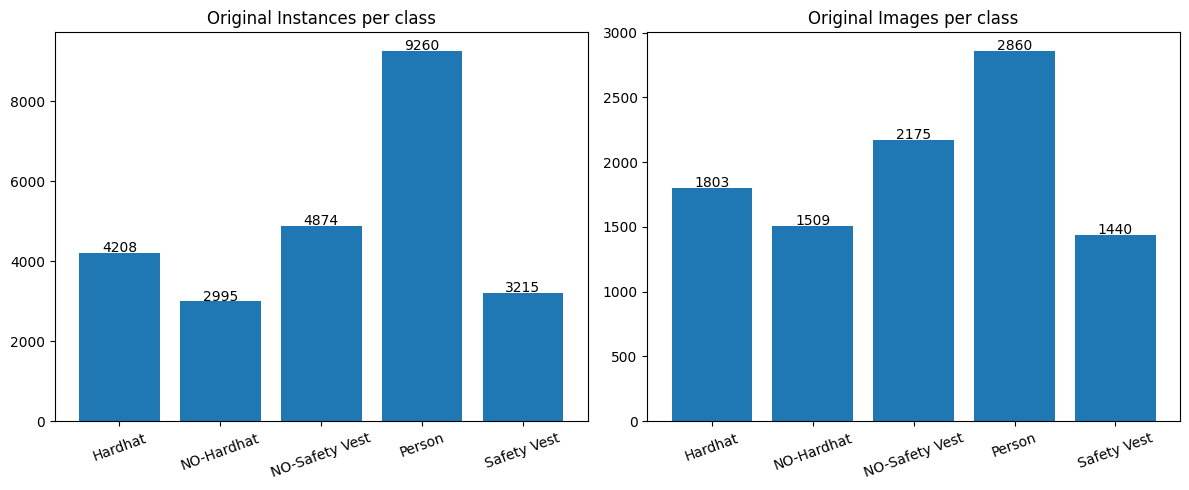


Pass A removed Person-only images: 88
Person count after Pass A: 9097
Pass B removed Person-dominant images: 565
Person count after Pass B: 6893

After aggressive undersampling
Hardhat         instances=3858   images=1583
NO-Hardhat      instances=2645   images=1265
NO-Safety Vest  instances=4200   images=1831
Person          instances=6893   images=2207
Safety Vest     instances=2820   images=1191


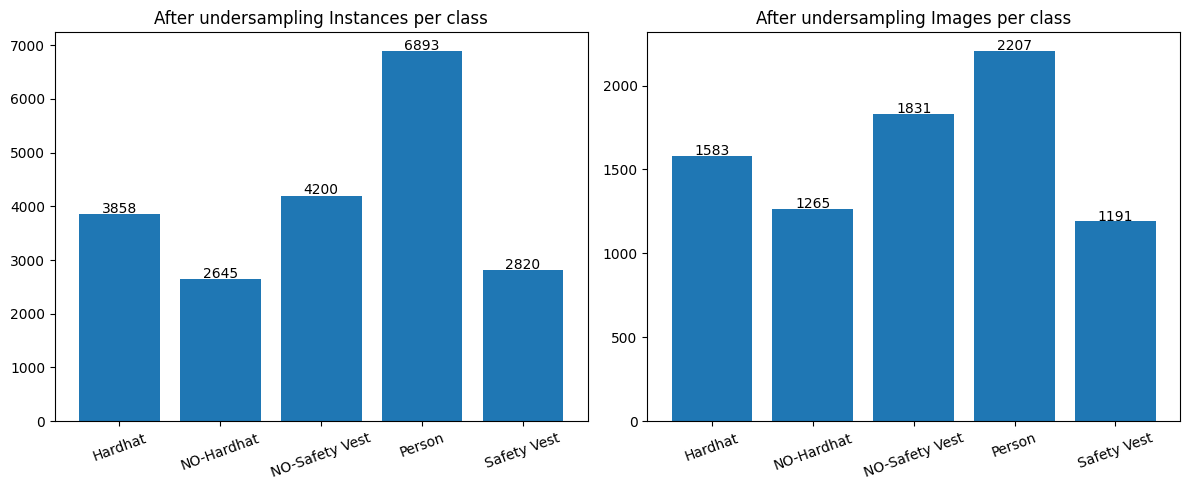


Stopped because no more safe augmentation candidates remained.

Final balanced training stats
Hardhat         instances=3858   images=1583
NO-Hardhat      instances=2645   images=1265
NO-Safety Vest  instances=4200   images=1831
Person          instances=6893   images=2207
Safety Vest     instances=2820   images=1191


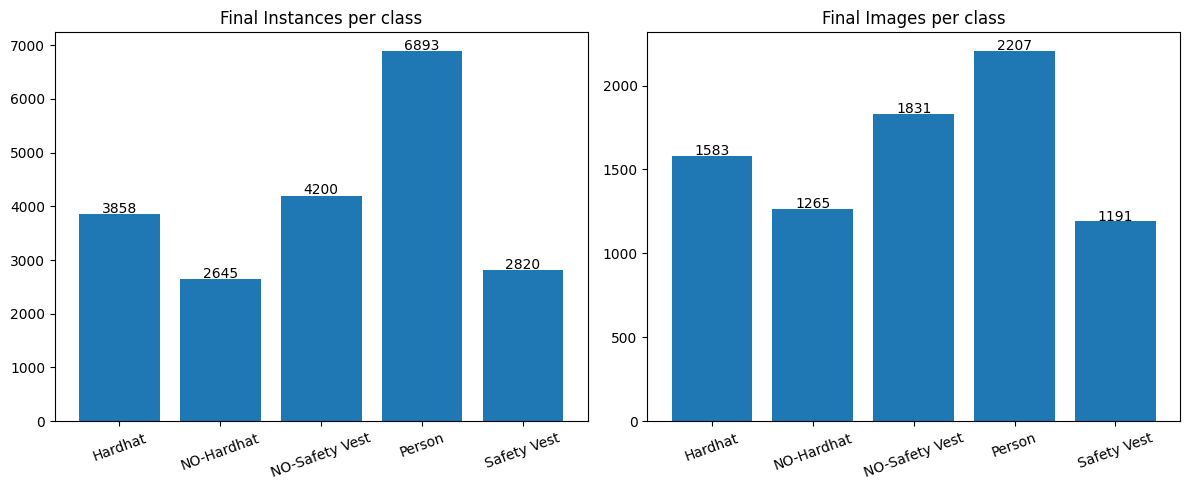


Total accepted augmentations: 0
Balanced dataset saved to: /content/aggressive-balanced-dataset


In [ ]:
# ============================================================
# AGGRESSIVE YOLO DATASET BALANCING
#   Bring classes into a healthier 4000-5000 range
#
# Strategy:
#   1) Strong Person undersampling
#   2) Strong augmentation for minority classes
#   3) Controlled acceptance checks
#
# Input:
#   /content/cleaned-construction-safety-dataset
#
# Output:
#   /content/aggressive-balanced-dataset
# ============================================================

from pathlib import Path
from collections import Counter, defaultdict
import shutil
import random
import cv2
import numpy as np
import albumentations as A
import matplotlib.pyplot as plt

# =========================
# PATHS
# =========================
DATASET_ROOT  = Path("/content/cleaned-construction-safety-dataset")
TRAIN_IMAGES  = DATASET_ROOT / "train" / "images"
TRAIN_LABELS  = DATASET_ROOT / "train" / "labels"

VALID_IMAGES  = DATASET_ROOT / "valid" / "images"
VALID_LABELS  = DATASET_ROOT / "valid" / "labels"

TEST_IMAGES   = DATASET_ROOT / "test" / "images"
TEST_LABELS   = DATASET_ROOT / "test" / "labels"

OUTPUT_ROOT   = Path("/content/aggressive-balanced-dataset")

# =========================
# CONFIG
# =========================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

CLASS_NAMES = {
    0: "Hardhat",
    1: "NO-Hardhat",
    2: "NO-Safety Vest",
    3: "Person",
    4: "Safety Vest",
}

PERSON_ID = 3
ALL_CLASS_IDS = [0, 1, 2, 3, 4]

# We mainly want to grow these
AUGMENT_TARGET_IDS = [1, 4]  # NO-Hardhat, Safety Vest

# Final desired targets
TARGET_COUNTS = {
    0: 4300,   # Hardhat
    1: 4300,   # NO-Hardhat
    2: 4700,   # NO-Safety Vest
    3: 5000,   # Person
    4: 4300,   # Safety Vest
}

TARGET_BUFFER = 100
MAX_AUG_PER_IMAGE = 8

# Relaxed caps so augmentation can actually proceed
PERSON_CAP_DURING_AUG = 5600
HARDHAT_CAP = 5200
NO_SAFETY_VEST_CAP = 5400

# =========================
# STRONGER ALBUMENTATIONS
# =========================
augment = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Affine(
        scale=(0.90, 1.10),
        translate_percent={"x": (-0.06, 0.06), "y": (-0.06, 0.06)},
        rotate=(-12, 12),
        shear=(-5, 5),
        fit_output=False,
        border_mode=cv2.BORDER_REFLECT_101,
        p=0.65
    ),
    A.Perspective(scale=(0.02, 0.05), p=0.20),
    A.RandomBrightnessContrast(
        brightness_limit=0.25,
        contrast_limit=0.25,
        p=0.50
    ),
    A.HueSaturationValue(
        hue_shift_limit=10,
        sat_shift_limit=14,
        val_shift_limit=12,
        p=0.35
    ),
    A.CLAHE(
        clip_limit=2.5,
        tile_grid_size=(8, 8),
        p=0.20
    ),
    A.GaussianBlur(
        blur_limit=(3, 5),
        p=0.10
    ),
], bbox_params=A.BboxParams(
    format="yolo",
    label_fields=["class_labels"],
    min_visibility=0.25
))

# =========================
# HELPERS
# =========================
def ensure_dir(path: Path):
    path.mkdir(parents=True, exist_ok=True)

def reset_output():
    if OUTPUT_ROOT.exists():
        shutil.rmtree(OUTPUT_ROOT)
    for split in ["train", "valid", "test"]:
        ensure_dir(OUTPUT_ROOT / split / "images")
        ensure_dir(OUTPUT_ROOT / split / "labels")

def copy_split(src_img_dir: Path, src_lbl_dir: Path, dst_img_dir: Path, dst_lbl_dir: Path):
    ensure_dir(dst_img_dir)
    ensure_dir(dst_lbl_dir)

    if src_img_dir.exists():
        for img in src_img_dir.iterdir():
            if img.is_file():
                shutil.copy2(img, dst_img_dir / img.name)

    if src_lbl_dir.exists():
        for lbl in src_lbl_dir.glob("*.txt"):
            shutil.copy2(lbl, dst_lbl_dir / lbl.name)

def find_image_for_label(stem: str, image_dir: Path):
    for ext in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]:
        p = image_dir / f"{stem}{ext}"
        if p.exists():
            return p
    return None

def clip_yolo_box(box, eps=1e-6):
    x, y, w, h = map(float, box)

    x = min(max(x, 0.0), 1.0)
    y = min(max(y, 0.0), 1.0)
    w = min(max(w, eps), 1.0)
    h = min(max(h, eps), 1.0)

    max_w = 2 * min(x, 1 - x) if 0 < x < 1 else 1.0
    max_h = 2 * min(y, 1 - y) if 0 < y < 1 else 1.0

    w = min(w, max(max_w, eps))
    h = min(h, max(max_h, eps))

    w = max(w, eps)
    h = max(h, eps)

    return [x, y, w, h]

def clean_yolo_boxes(class_ids, bboxes, eps=1e-6):
    clean_classes = []
    clean_boxes = []

    for cls, box in zip(class_ids, bboxes):
        try:
            x, y, w, h = map(float, box)
        except:
            continue

        if w <= 0 or h <= 0:
            continue

        box = clip_yolo_box([x, y, w, h], eps=eps)
        x, y, w, h = box

        x_min = x - w / 2
        y_min = y - h / 2
        x_max = x + w / 2
        y_max = y + h / 2

        tol = 1e-5
        if x_min < -tol or y_min < -tol or x_max > 1 + tol or y_max > 1 + tol:
            continue

        clean_classes.append(int(cls))
        clean_boxes.append([x, y, w, h])

    return clean_classes, clean_boxes

def read_yolo_label(label_path: Path):
    class_ids = []
    bboxes = []

    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            try:
                cls = int(float(parts[0]))
                x, y, w, h = map(float, parts[1:5])
                class_ids.append(cls)
                bboxes.append([x, y, w, h])
            except:
                continue

    return clean_yolo_boxes(class_ids, bboxes)

def write_yolo_label(label_path: Path, class_ids, bboxes):
    with open(label_path, "w") as f:
        for cls, box in zip(class_ids, bboxes):
            x, y, w, h = box
            f.write(f"{int(cls)} {x:.6f} {y:.6f} {w:.6f} {h:.6f}\n")

def get_records(image_dir: Path, label_dir: Path):
    records = []

    for lbl_path in sorted(label_dir.glob("*.txt")):
        stem = lbl_path.stem
        img_path = find_image_for_label(stem, image_dir)
        if img_path is None:
            continue

        class_ids, bboxes = read_yolo_label(lbl_path)
        if not class_ids:
            continue

        counts = Counter(class_ids)
        total_objs = sum(counts.values())
        person_count = counts.get(PERSON_ID, 0)
        non_person_count = total_objs - person_count
        person_ratio = person_count / max(total_objs, 1)

        records.append({
            "stem": stem,
            "img_path": img_path,
            "lbl_path": lbl_path,
            "class_ids": class_ids,
            "bboxes": bboxes,
            "counts": counts,
            "class_set": set(counts.keys()),
            "person_count": person_count,
            "non_person_count": non_person_count,
            "person_ratio": person_ratio,
            "only_person": set(counts.keys()) == {PERSON_ID},
        })

    return records

def summarize_records(records):
    instance_counts = Counter()
    image_counts = Counter()

    for r in records:
        instance_counts.update(r["counts"])
        for cid in r["class_set"]:
            image_counts[cid] += 1

    return instance_counts, image_counts

def count_dir_stats(label_dir: Path):
    instance_counts = Counter()
    image_counts = Counter()

    for lbl_file in label_dir.glob("*.txt"):
        classes_in_image = set()
        with open(lbl_file, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    try:
                        cls = int(float(parts[0]))
                        instance_counts[cls] += 1
                        classes_in_image.add(cls)
                    except:
                        pass
        for cls in classes_in_image:
            image_counts[cls] += 1

    return instance_counts, image_counts

def print_stats(title, instance_counts, image_counts):
    print(f"\n{title}")
    for cid in ALL_CLASS_IDS:
        print(f"{CLASS_NAMES[cid]:<15} instances={instance_counts[cid]:<6} images={image_counts[cid]}")

def plot_stats(instance_counts, image_counts, title_prefix=""):
    names = [CLASS_NAMES[cid] for cid in ALL_CLASS_IDS]
    inst_values = [instance_counts[cid] for cid in ALL_CLASS_IDS]
    img_values = [image_counts[cid] for cid in ALL_CLASS_IDS]

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    bars = plt.bar(names, inst_values)
    plt.title(f"{title_prefix} Instances per class")
    plt.xticks(rotation=20)
    for b, v in zip(bars, inst_values):
        plt.text(b.get_x() + b.get_width()/2, v + 20, str(v), ha="center")

    plt.subplot(1, 2, 2)
    bars = plt.bar(names, img_values)
    plt.title(f"{title_prefix} Images per class")
    plt.xticks(rotation=20)
    for b, v in zip(bars, img_values):
        plt.text(b.get_x() + b.get_width()/2, v + 5, str(v), ha="center")

    plt.tight_layout()
    plt.show()

def save_record(record, out_img_dir: Path, out_lbl_dir: Path):
    shutil.copy2(record["img_path"], out_img_dir / record["img_path"].name)
    shutil.copy2(record["lbl_path"], out_lbl_dir / record["lbl_path"].name)

def remove_saved_sample(base_name: str):
    img = OUT_TRAIN_IMAGES / f"{base_name}.jpg"
    lbl = OUT_TRAIN_LABELS / f"{base_name}.txt"
    if img.exists():
        img.unlink()
    if lbl.exists():
        lbl.unlink()

def save_augmented_sample(record, suffix):
    image = cv2.imread(str(record["img_path"]))
    if image is None:
        return None, None

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    class_ids, bboxes = clean_yolo_boxes(record["class_ids"], record["bboxes"])
    if len(bboxes) == 0:
        return None, None

    try:
        transformed = augment(
            image=image,
            bboxes=bboxes,
            class_labels=class_ids
        )
    except ValueError:
        return None, None

    aug_img = transformed["image"]
    aug_boxes = transformed["bboxes"]
    aug_classes = transformed["class_labels"]

    if len(aug_boxes) == 0:
        return None, None

    aug_classes, aug_boxes = clean_yolo_boxes(aug_classes, aug_boxes)
    if len(aug_boxes) == 0:
        return None, None

    base_name = f"{record['stem']}_{suffix}"
    out_img_path = OUT_TRAIN_IMAGES / f"{base_name}.jpg"
    out_lbl_path = OUT_TRAIN_LABELS / f"{base_name}.txt"

    cv2.imwrite(str(out_img_path), cv2.cvtColor(aug_img, cv2.COLOR_RGB2BGR))
    write_yolo_label(out_lbl_path, aug_classes, aug_boxes)

    return Counter(aug_classes), set(aug_classes)

# =========================
# STEP 1: RESET + COPY VALID/TEST
# =========================
reset_output()

copy_split(
    VALID_IMAGES, VALID_LABELS,
    OUTPUT_ROOT / "valid" / "images",
    OUTPUT_ROOT / "valid" / "labels"
)
copy_split(
    TEST_IMAGES, TEST_LABELS,
    OUTPUT_ROOT / "test" / "images",
    OUTPUT_ROOT / "test" / "labels"
)

yaml_file = DATASET_ROOT / "data.yaml"
if yaml_file.exists():
    shutil.copy2(yaml_file, OUTPUT_ROOT / "data.yaml")

# =========================
# STEP 2: LOAD TRAIN SET
# =========================
records = get_records(TRAIN_IMAGES, TRAIN_LABELS)
orig_instance_counts, orig_image_counts = summarize_records(records)
print_stats("Original training stats", orig_instance_counts, orig_image_counts)
plot_stats(orig_instance_counts, orig_image_counts, "Original")

# =========================
# STEP 3: STRONG UNDERSAMPLING
# A) Remove Person-only images
# B) Remove Person-dominant images aggressively
# =========================
kept_by_stem = {r["stem"]: r for r in records}
current_counts = orig_instance_counts.copy()

# A) Person-only
person_only = [r for r in records if r["only_person"] and r["person_count"] > 0]
person_only.sort(key=lambda r: r["person_count"], reverse=True)

removed_A = 0
for r in person_only:
    if current_counts[PERSON_ID] <= TARGET_COUNTS[PERSON_ID] + TARGET_BUFFER:
        break

    projected_person = current_counts[PERSON_ID] - r["person_count"]
    if projected_person < TARGET_COUNTS[PERSON_ID] - TARGET_BUFFER:
        continue

    kept_by_stem.pop(r["stem"], None)
    current_counts.subtract(r["counts"])
    removed_A += 1

print(f"\nPass A removed Person-only images: {removed_A}")
print(f"Person count after Pass A: {current_counts[PERSON_ID]}")

# B) Person-dominant
remaining_records = list(kept_by_stem.values())

person_dominant = []
for r in remaining_records:
    if r["person_count"] <= 0:
        continue
    if r["only_person"]:
        continue

    # More aggressive threshold
    if r["person_ratio"] >= 0.50 and r["person_count"] >= 2:
        person_dominant.append(r)

# remove more person-heavy and less useful images first
person_dominant.sort(
    key=lambda r: (
        -r["person_ratio"],
        -r["person_count"],
        r["counts"].get(1, 0) + r["counts"].get(4, 0),  # protect NO-Hardhat + Safety Vest a bit
        r["non_person_count"]
    )
)

removed_B = 0
for r in person_dominant:
    if current_counts[PERSON_ID] <= TARGET_COUNTS[PERSON_ID] + TARGET_BUFFER:
        break

    projected = current_counts.copy()
    projected.subtract(r["counts"])

    # keep useful minority classes from collapsing too much
    if projected[1] < 2400:
        continue
    if projected[4] < 2600:
        continue
    if projected[0] < 3600:
        continue
    if projected[2] < 4200:
        continue
    if projected[PERSON_ID] < TARGET_COUNTS[PERSON_ID] - TARGET_BUFFER:
        continue

    kept_by_stem.pop(r["stem"], None)
    current_counts = projected
    removed_B += 1

print(f"Pass B removed Person-dominant images: {removed_B}")
print(f"Person count after Pass B: {current_counts[PERSON_ID]}")

kept_records = list(kept_by_stem.values())
under_instance_counts, under_image_counts = summarize_records(kept_records)
print_stats("After aggressive undersampling", under_instance_counts, under_image_counts)
plot_stats(under_instance_counts, under_image_counts, "After undersampling")

# =========================
# STEP 4: SAVE UNDERSAMPLED TRAIN
# =========================
OUT_TRAIN_IMAGES = OUTPUT_ROOT / "train" / "images"
OUT_TRAIN_LABELS = OUTPUT_ROOT / "train" / "labels"

for r in kept_records:
    save_record(r, OUT_TRAIN_IMAGES, OUT_TRAIN_LABELS)

# =========================
# STEP 5: PREPARE AUGMENTATION
# =========================
source_records = kept_records[:]
current_instance_counts = under_instance_counts.copy()
current_image_counts = under_image_counts.copy()

candidates_by_class = defaultdict(list)
for r in source_records:
    for cid in AUGMENT_TARGET_IDS:
        if r["counts"].get(cid, 0) > 0:
            candidates_by_class[cid].append(r)

# Prefer images with more target class and fewer Person
for cid in AUGMENT_TARGET_IDS:
    candidates_by_class[cid].sort(
        key=lambda r: (
            -r["counts"].get(cid, 0),
            r["person_count"],
            sum(r["counts"].values())
        )
    )

aug_used = defaultdict(int)
aug_global_idx = 0

# =========================
# STEP 6: STRONG AUGMENTATION
# =========================
max_rounds = 30000
round_idx = 0
accepted_aug = 0

while round_idx < max_rounds:
    round_idx += 1
    progress = False

    class_order = sorted(
        AUGMENT_TARGET_IDS,
        key=lambda cid: TARGET_COUNTS[cid] - current_instance_counts[cid],
        reverse=True
    )

    done = True
    for cid in AUGMENT_TARGET_IDS:
        if current_instance_counts[cid] < TARGET_COUNTS[cid] - TARGET_BUFFER:
            done = False
            break

    if done:
        print("\nAll augmentation targets reached.")
        break

    for target_cid in class_order:
        if current_instance_counts[target_cid] >= TARGET_COUNTS[target_cid] - TARGET_BUFFER:
            continue

        for rec in candidates_by_class[target_cid]:
            if aug_used[rec["stem"]] >= MAX_AUG_PER_IMAGE:
                continue

            suffix = f"aug_{target_cid}_{aug_used[rec['stem']] + 1}_{aug_global_idx}"
            base_name = f"{rec['stem']}_{suffix}"

            aug_counts, aug_class_set = save_augmented_sample(rec, suffix)
            if aug_counts is None:
                continue

            projected = current_instance_counts.copy()
            projected.update(aug_counts)

            # relaxed acceptance rules
            if projected[PERSON_ID] > PERSON_CAP_DURING_AUG:
                remove_saved_sample(base_name)
                continue

            if projected[target_cid] > TARGET_COUNTS[target_cid] + TARGET_BUFFER:
                remove_saved_sample(base_name)
                continue

            if projected[0] > HARDHAT_CAP:
                remove_saved_sample(base_name)
                continue

            if projected[2] > NO_SAFETY_VEST_CAP:
                remove_saved_sample(base_name)
                continue

            current_instance_counts = projected
            for cid in aug_class_set:
                current_image_counts[cid] += 1

            aug_used[rec["stem"]] += 1
            aug_global_idx += 1
            accepted_aug += 1
            progress = True

            if accepted_aug % 25 == 0:
                print(f"Accepted augmentations: {accepted_aug}")
                print(f"Current counts: {dict(current_instance_counts)}")
            break

    if not progress:
        print("\nStopped because no more safe augmentation candidates remained.")
        break

# =========================
# STEP 7: FINAL STATS
# =========================
final_instance_counts, final_image_counts = count_dir_stats(OUT_TRAIN_LABELS)

print_stats("Final balanced training stats", final_instance_counts, final_image_counts)
plot_stats(final_instance_counts, final_image_counts, "Final")

print(f"\nTotal accepted augmentations: {accepted_aug}")
print(f"Balanced dataset saved to: {OUTPUT_ROOT}")

## 4. Verify data.yaml

In [22]:
import yaml
from pathlib import Path

# Read the original data.yaml from Roboflow download
src_yaml = Path(DATASET_PATH) / "data.yaml"
with open(src_yaml) as f:
    cfg = yaml.safe_load(f)

DATASET_PATH_FINAL = "/content/aggressive-balanced-dataset"

# FIX: point to the augmented / cleaned split folders
cfg["train"] = str(Path(DATASET_PATH_FINAL) / "train" / "images")
cfg["val"]   = str(Path(DATASET_PATH_FINAL) / "valid" / "images")  # folder is 'valid'
cfg["test"]  = str(Path(DATASET_PATH_FINAL) / "test"  / "images")

# Remap Roboflow class names → project convention
NAME_REMAP = {
    "Hardhat"        : "hard_hat",
    "NO-Hardhat"     : "no_hard_hat",
    "Safety Vest"    : "safety_vest",
    "NO-Safety Vest" : "no_safety_vest",
    "Person"         : "person",
}

original_names = cfg.get("names", [])
remapped_names = []
for n in original_names:
    mapped = NAME_REMAP.get(n, None)
    if mapped is None:
        print(f"[WARN] No remap found for class '{n}' — keeping as-is")
        mapped = n
    remapped_names.append(mapped)
cfg["names"] = remapped_names
cfg["nc"]    = len(remapped_names)

# FIX: write updated yaml to the cleaned/augmented dataset directory
out_yaml = Path(DATASET_PATH_FINAL) / "data.yaml"
out_yaml.parent.mkdir(parents=True, exist_ok=True)
with open(out_yaml, "w") as f:
    yaml.dump(cfg, f, default_flow_style=False, sort_keys=False)

# Update the global yaml_path used by training cell
yaml_path = out_yaml

print("data.yaml written to:", yaml_path)
print()
print(yaml.dump(cfg, default_flow_style=False, sort_keys=False))


data.yaml written to: /content/aggressive-balanced-dataset/data.yaml

names:
- hard_hat
- no_hard_hat
- no_safety_vest
- person
- safety_vest
nc: 5
roboflow:
  license: CC BY 4.0
  project: construction-safety-gsnvb-amiuj
  url: https://universe.roboflow.com/hashinifdo/construction-safety-gsnvb-amiuj/dataset/3
  version: 3
  workspace: hashinifdo
test: /content/aggressive-balanced-dataset/test/images
train: /content/aggressive-balanced-dataset/train/images
val: /content/aggressive-balanced-dataset/valid/images



In [13]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 5. Model Training

In [ ]:
from ultralytics import YOLO

# Load pretrained YOLOv8m (COCO weights — transfer learning)
model = YOLO('yolov8m.pt')

results = model.train(
    data=str(yaml_path),
    epochs=100,
    imgsz=640,
    batch=16,             # safe for T4 16GB; increase to 32 on A100
    optimizer='AdamW',
    lr0=0.001,
    lrf=0.01,             # final LR = lr0 * lrf (cosine decay)
    weight_decay=0.0005,
    warmup_epochs=3,
    warmup_momentum=0.8,
    # Augmentation
    mosaic=1.0,           # mosaic augmentation — critical for multi-scale workers
    mixup=0.1,
    copy_paste=0.1,       # copy-paste augmentation for small object diversity
    close_mosaic=10,      # disable mosaic last 10 epochs for stable convergence
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    flipud=0.0,           # no vertical flip (workers don't appear upside down)
    fliplr=0.5,
    # Training control
    patience=20,          # early stopping if no improvement for 20 epochs
    save_period=10,       # checkpoint every 10 epochs
    val=True,
    plots=True,           # saves training curves automatically
    project='construction_safety',
    name='yolov8m_run1',
    exist_ok=True,
    verbose=True,
)

print('\nTraining complete!')
print(f'Best weights: construction_safety/yolov8m_run1/weights/best.pt')

Ultralytics 8.4.32 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/aggressive-balanced-dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8m_run1, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True,

In [ ]:
# Download weights to local machine
from google.colab import files
files.download('construction_safety/yolov8m_run1/weights/best.pt')

In [ ]:


import shutil

SOURCE = '/content/runs/detect/construction_safety'
DEST = '/content/drive/MyDrive/construction_safety_run1'

shutil.copytree(SOURCE, DEST, dirs_exist_ok=True)

print("Full folder copied successfully!")

Full folder copied successfully!


## 6. Evaluation

In [ ]:
# Load best weights and evaluate on test set
best_model = YOLO('/content/runs/detect/construction_safety/yolov8m_run1/weights/best.pt')

metrics = best_model.val(
    data=str(yaml_path),
    split='test',
    imgsz=640,
    conf=0.25,
    iou=0.45,
    plots=True,
    save_json=True,
)

print('\n=== Test Set Results ===')
print(f'mAP@50      : {metrics.box.map50:.4f}')
print(f'mAP@50-95   : {metrics.box.map:.4f}')
print(f'Precision   : {metrics.box.mp:.4f}')
print(f'Recall      : {metrics.box.mr:.4f}')
print()
print('Per-class AP@50:')
for i, name in enumerate(names):
    if i < len(metrics.box.ap50):
        print(f'  {name:<20} {metrics.box.ap50[i]:.4f}')

Ultralytics 8.4.32 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,842,655 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 51.3±19.4 MB/s, size: 133.3 KB)
val: Scanning /content/aggressive-balanced-dataset/test/labels... 461 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 461/461 522.2it/s 0.9s
val: New cache created: /content/aggressive-balanced-dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 29/29 1.9it/s 15.6s
                   all        461       3524      0.869      0.791      0.863       0.61
              hard_hat        258        619      0.869      0.822      0.876      0.559
           no_hard_hat        210        446      0.856       0.76      0.835      0.549
        no_safety_vest        323        721      0.849      0.775      0.847        0.6
                person        405       1323 

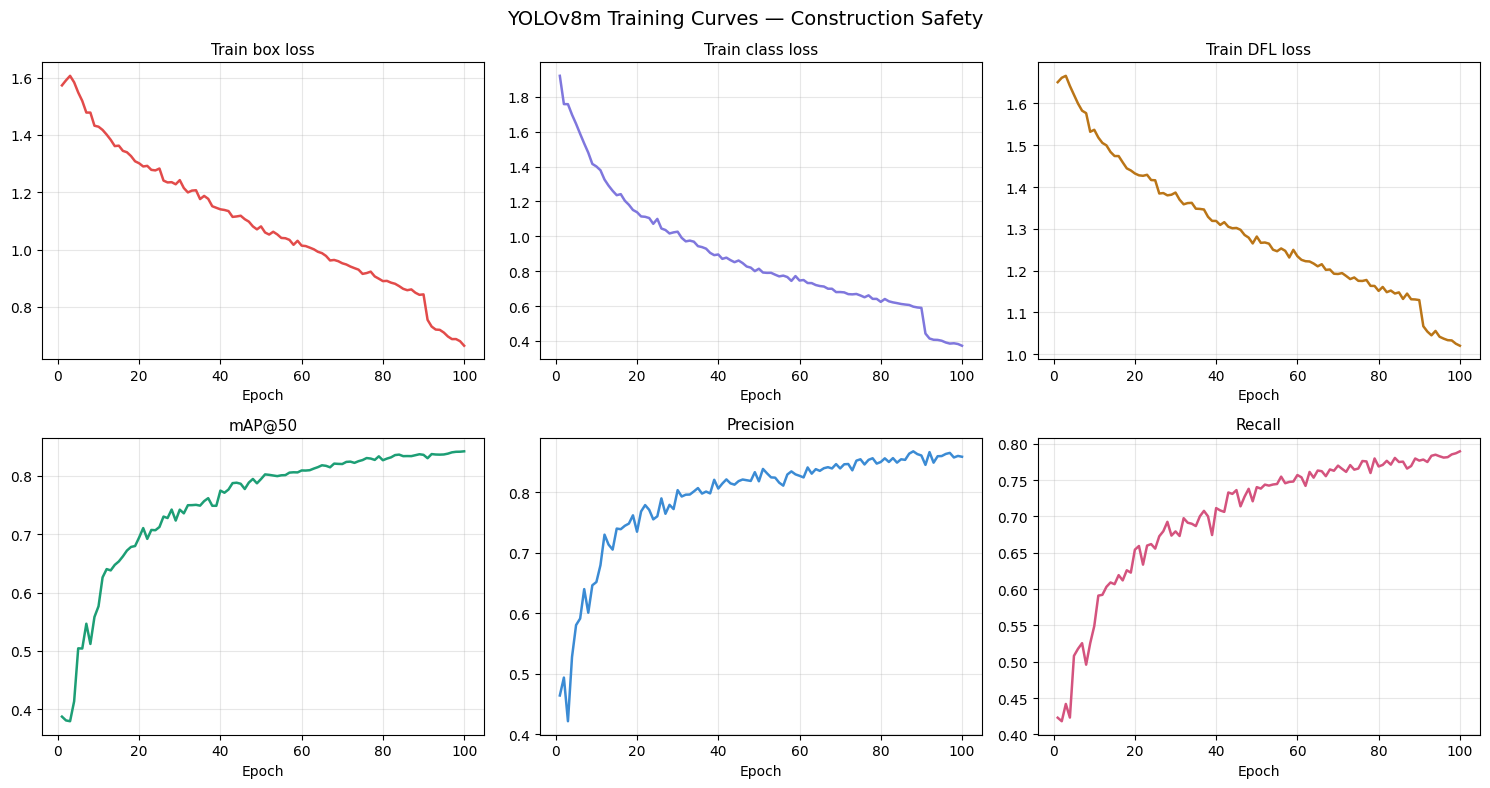

Saved: training_curves.png


In [ ]:
# Plot training curves from results.csv
import pandas as pd
import matplotlib.pyplot as plt

results_csv = Path('/content/runs/detect/construction_safety/yolov8m_run1/results.csv')
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('YOLOv8m Training Curves — Construction Safety', fontsize=14)

plot_pairs = [
    ('train/box_loss',  'Train box loss',      axes[0,0]),
    ('train/cls_loss',  'Train class loss',    axes[0,1]),
    ('train/dfl_loss',  'Train DFL loss',      axes[0,2]),
    ('metrics/mAP50(B)','mAP@50',              axes[1,0]),
    ('metrics/precision(B)', 'Precision',      axes[1,1]),
    ('metrics/recall(B)',    'Recall',          axes[1,2]),
]

colors_plot = ['#E24B4A','#7F77DD','#BA7517','#1D9E75','#3B8BD4','#D4537E']
for (col, title, ax), color in zip(plot_pairs, colors_plot):
    if col in df.columns:
        ax.plot(df['epoch'], df[col], color=color, linewidth=1.8)
        ax.set_title(title, fontsize=11)
        ax.set_xlabel('Epoch')
        ax.grid(alpha=0.3)
    else:
        ax.set_title(f'{title} (not found)', fontsize=11)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_curves.png')

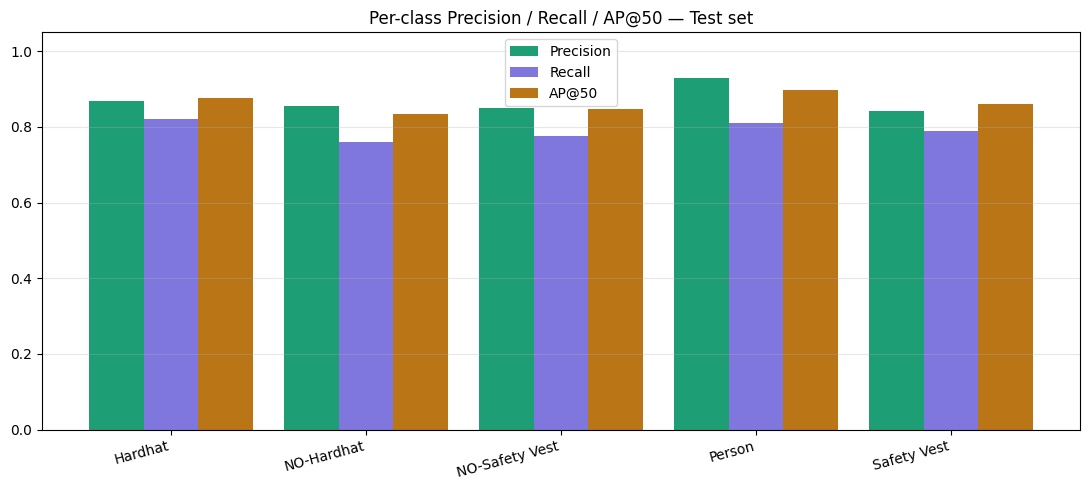

Saved: per_class_metrics.png


In [ ]:
# Confusion matrix + per-class precision-recall bar chart
from ultralytics.utils.plotting import plot_results

# Per-class precision / recall bar chart
class_names = data_cfg['names']
precisions  = list(metrics.box.p)
recalls     = list(metrics.box.r)
ap50s       = list(metrics.box.ap50)

x = np.arange(len(class_names))
width = 0.28

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width, precisions, width, label='Precision', color='#1D9E75',   edgecolor='none')
ax.bar(x,          recalls,   width, label='Recall',    color='#7F77DD',   edgecolor='none')
ax.bar(x + width,  ap50s,     width, label='AP@50',     color='#BA7517',   edgecolor='none')
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=15, ha='right')
ax.set_ylim(0, 1.05)
ax.set_title('Per-class Precision / Recall / AP@50 — Test set', fontsize=12)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('per_class_metrics.png', dpi=150)
plt.show()
print('Saved: per_class_metrics.png')

## 7. Inference & Violation Detection

## Worker–PPE Association and Compliance Rule Engine

Object detection alone is not sufficient to determine whether a construction scene is safe or unsafe. After detecting workers and PPE items, an additional rule-based reasoning layer was applied to associate PPE with each worker and evaluate compliance.

### Why this step is needed

The detection model predicts separate objects such as:
- `person`
- `hard_hat`
- `safety_vest`
- `no_hard_hat`
- `no_safety_vest`

However, these detections must be interpreted at the **worker level** to answer the core safety question:

> Is each detected worker compliant with the required PPE rules?

This post-processing step converts raw detections into structured worker-specific safety reports.

---

### Association logic

Each detected PPE item is matched to a worker using spatial reasoning:

1. **IoU-based matching**
   - If the PPE bounding box overlaps sufficiently with a worker bounding box, it is associated with that worker.

2. **Centroid fallback**
   - If IoU is low, the centroid of the PPE box is checked.
   - If the centroid lies inside the worker box, the PPE is still associated with that worker.

This helps handle cases where PPE occupies only a small part of the worker region.

---

### Compliance rules

For each worker, the system checks whether the required PPE is present.

Required PPE:
- Hard hat
- Safety vest

Violation conditions:
- `no_hard_hat` detected near the worker → **Missing hard hat**
- `no_safety_vest` detected near the worker → **Missing safety vest**
- No PPE detected near the worker → flagged as:
  - *No PPE detected — worker may be unequipped or occluded*

Each worker is then assigned:
- **Compliant** or **Violation**
- Mean confidence score
- Uncertainty flag if any related detection confidence is below a threshold

---

### Uncertainty handling

Predictions with confidence below a defined uncertainty threshold are surfaced as uncertain rather than being treated as fully reliable. This helps improve transparency and supports manual review in ambiguous cases.

This is especially useful for:
- occluded workers
- small distant workers
- poor lighting conditions
- partially visible PPE

---

### Output

The rule engine produces a structured JSON safety report containing:
- overall verdict (`SAFE` / `UNSAFE`)
- total number of workers
- number of compliant workers
- number of violations
- per-worker violation details
- confidence and uncertainty information

This makes the system more interpretable and closer to a real-world safety monitoring application.


In [ ]:
import json
from dataclasses import dataclass, asdict
from typing import List, Optional

# ---------------------------------------------------------------
# Worker-PPE association + compliance rule engine
# ---------------------------------------------------------------

@dataclass
class Detection:
    cls:    str
    conf:   float
    box:    List[float]   # [x1, y1, x2, y2] normalised 0-1

@dataclass
class WorkerReport:
    worker_id:    int
    compliant:    bool
    violations:   List[str]
    confidence:   float       # mean detection confidence
    uncertain:    bool        # flagged if any conf < UNCERTAINTY_THRESH
    box:          List[float]


REQUIRED_PPE       = ['hard_hat', 'safety_vest']
VIOLATION_CLASSES  = {'no_hard_hat', 'no_safety_vest'}
CONF_THRESH        = 0.35
UNCERTAINTY_THRESH = 0.50   # surface predictions below this as uncertain


def iou(box_a, box_b):
    """Compute IoU between two [x1,y1,x2,y2] boxes."""
    xa = max(box_a[0], box_b[0]); ya = max(box_a[1], box_b[1])
    xb = min(box_a[2], box_b[2]); yb = min(box_a[3], box_b[3])
    inter = max(0, xb - xa) * max(0, yb - ya)
    area_a = (box_a[2]-box_a[0]) * (box_a[3]-box_a[1])
    area_b = (box_b[2]-box_b[0]) * (box_b[3]-box_b[1])
    union = area_a + area_b - inter
    return inter / union if union > 0 else 0.0


def associate_ppe_to_workers(detections: List[Detection]) -> List[WorkerReport]:
    """Match PPE detections to worker bounding boxes using IoU overlap."""
    workers = [d for d in detections if d.cls == 'person']
    ppe     = [d for d in detections if d.cls != 'person']
    reports = []

    for w_idx, worker in enumerate(workers):
        worker_ppe = []
        for item in ppe:
            # PPE must spatially overlap the worker
            if iou(worker.box, item.box) > 0.1:
                worker_ppe.append(item)
            else:
                # Fallback: centroid of PPE within worker box
                cx = (item.box[0] + item.box[2]) / 2
                cy = (item.box[1] + item.box[3]) / 2
                if (worker.box[0] <= cx <= worker.box[2] and
                    worker.box[1] <= cy <= worker.box[3]):
                    worker_ppe.append(item)

        # Compliance rules
        violations = []
        ppe_present = {item.cls for item in worker_ppe}

        if 'no_hard_hat'    in ppe_present: violations.append('Missing hard hat')
        if 'no_safety_vest' in ppe_present: violations.append('Missing safety vest')
        # If no PPE detected at all near this worker, flag as non-compliant
        if not ppe_present:
            violations.append('No PPE detected — worker may be unequipped or occluded')

        all_confs   = [worker.conf] + [p.conf for p in worker_ppe]
        mean_conf   = sum(all_confs) / len(all_confs)
        uncertain   = any(c < UNCERTAINTY_THRESH for c in all_confs)

        reports.append(WorkerReport(
            worker_id  = w_idx + 1,
            compliant  = len(violations) == 0,
            violations = violations,
            confidence = round(mean_conf, 3),
            uncertain  = uncertain,
            box        = [round(v, 4) for v in worker.box],
        ))

    return reports


def generate_violation_report(image_path: str, reports: List[WorkerReport]) -> dict:
    """Generate a structured JSON safety report for an image."""
    total       = len(reports)
    compliant   = sum(1 for r in reports if r.compliant)
    violations  = total - compliant
    uncertain   = sum(1 for r in reports if r.uncertain)

    overall = 'SAFE' if violations == 0 else 'UNSAFE'
    if uncertain > 0:
        overall += f' ( {uncertain} uncertain detection(s) — manual review recommended)'

    return {
        'image'        : image_path,
        'verdict'      : overall,
        'workers_total': total,
        'compliant'    : compliant,
        'violations'   : violations,
        'workers'      : [
            {
                'id'        : r.worker_id,
                'status'    : 'COMPLIANT' if r.compliant else 'VIOLATION',
                'violations': r.violations,
                'confidence': r.confidence,
                'uncertain' : r.uncertain,
            }
            for r in reports
        ]
    }

print('Inference functions loaded.')

Inference functions loaded.


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:

from ultralytics import YOLO
best_model = YOLO('/content/drive/MyDrive/construction_safety_run1/yolov8m_run1/weights/best.pt')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


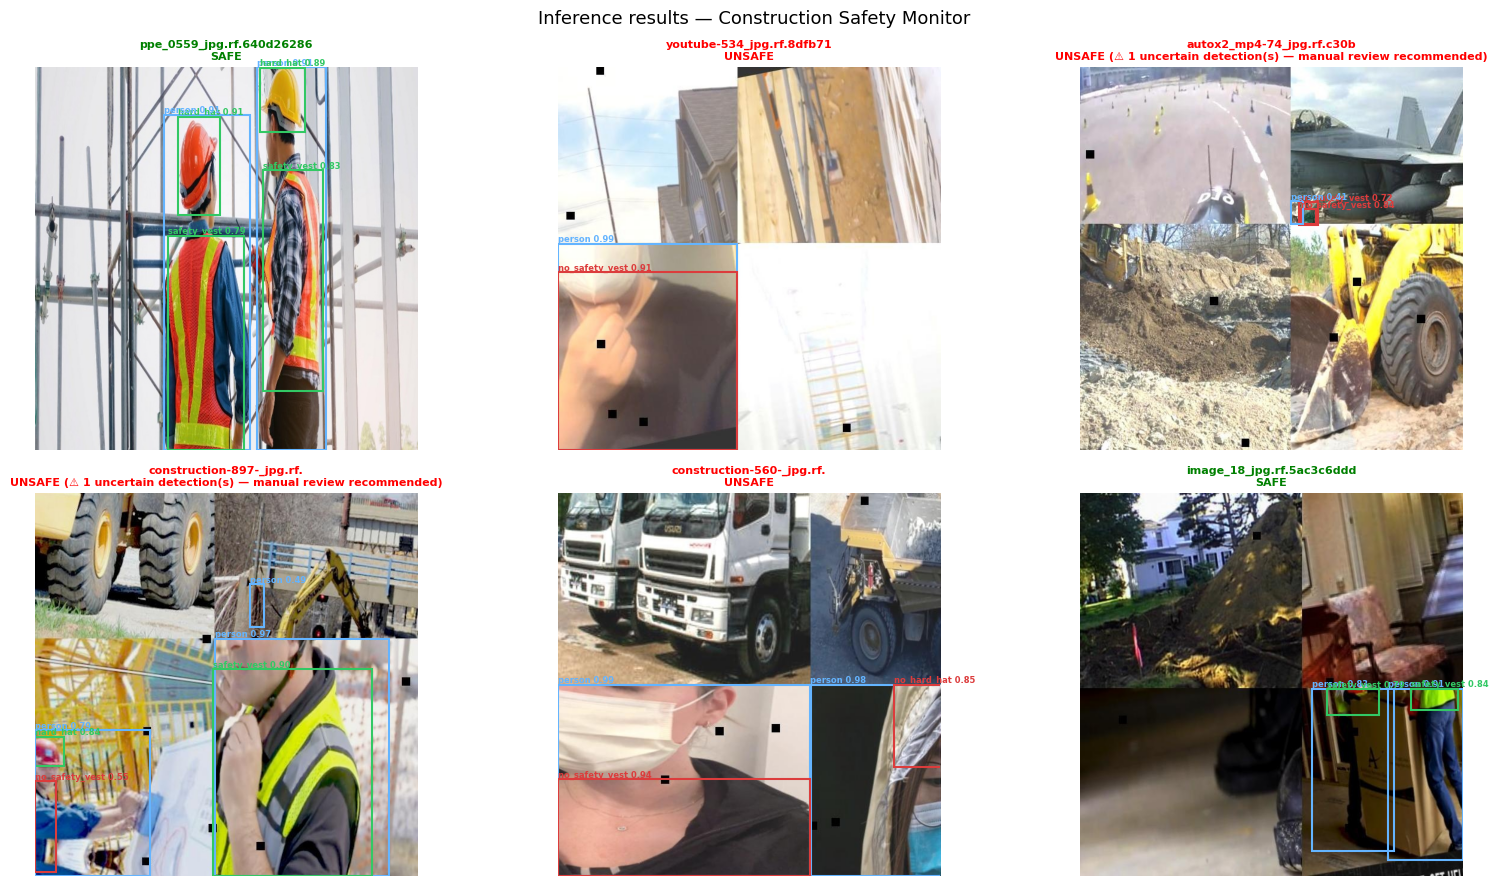

{
  "image": "ppe_0559_jpg.rf.640d26286294e16e9f84a6abb4b5be74.jpg",
  "verdict": "SAFE",
  "workers_total": 2,
  "compliant": 2,
  "violations": 0,
  "workers": [
    {
      "id": 1,
      "status": "COMPLIANT",
      "violations": [],
      "confidence": 0.87,
      "uncertain": false
    },
    {
      "id": 2,
      "status": "COMPLIANT",
      "violations": [],
      "confidence": 0.877,
      "uncertain": false
    }
  ]
}
---
{
  "image": "youtube-534_jpg.rf.8dfb71cabc61c4444de0fedcfd519a4a.jpg",
  "verdict": "UNSAFE",
  "workers_total": 1,
  "compliant": 0,
  "violations": 1,
  "workers": [
    {
      "id": 1,
      "status": "VIOLATION",
      "violations": [
        "Missing safety vest"
      ],
      "confidence": 0.947,
      "uncertain": false
    }
  ]
}
---
{
  "image": "autox2_mp4-74_jpg.rf.c30bd7eb05d1ec8de02a92bd62a94c60.jpg",
  "verdict": "UNSAFE (\u26a0 1 uncertain detection(s) \u2014 manual review recommended)",
  "workers_total": 1,
  "compliant": 0,
  "violati

In [23]:
# Run inference on test images and visualise results
import cv2
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches

test_img_dir = Path(DATASET_PATH_FINAL) / 'test' / 'images'
test_images  = list(test_img_dir.glob('*.jpg'))[:6]   # sample 6
random.shuffle(test_images)

COLORS = {
    'person'         : (100, 180, 255),
    'hard_hat'       : (50,  200, 100),
    'safety_vest'    : (50,  200, 100),
    'no_hard_hat'    : (220,  60,  60),
    'no_safety_vest' : (220,  60,  60),
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

all_reports = []

for ax, img_path in zip(axes, test_images):
    preds = best_model.predict(str(img_path), conf=CONF_THRESH, verbose=False)[0]
    img   = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    ih, iw = img.shape[:2]

    detections = []
    for box in preds.boxes:
        cls_name = preds.names[int(box.cls)]
        conf     = float(box.conf)
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        detections.append(Detection(
            cls=cls_name, conf=conf,
            box=[x1/iw, y1/ih, x2/iw, y2/ih]
        ))
        # Draw box
        color = [c/255 for c in COLORS.get(cls_name, (180,180,180))]
        rect  = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                   linewidth=1.5, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1-4, f'{cls_name} {conf:.2f}',
                color=color, fontsize=6, fontweight='bold')

    reports = associate_ppe_to_workers(detections)
    report  = generate_violation_report(img_path.name, reports)
    all_reports.append(report)

    verdict = report['verdict']
    title_color = 'green' if verdict.startswith('SAFE') else 'red'
    ax.imshow(img)
    ax.set_title(f'{img_path.name[:25]}\n{verdict}',
                 fontsize=8, color=title_color, fontweight='bold')
    ax.axis('off')

plt.suptitle('Inference results — Construction Safety Monitor', fontsize=13)
plt.tight_layout()
plt.savefig('inference_results.png', dpi=150, bbox_inches='tight')
plt.show()

# Print JSON reports
for r in all_reports:
    print(json.dumps(r, indent=2))
    print('---')

Saving 62a59cc649895f3c47f1bfbf36164b21.jpg to 62a59cc649895f3c47f1bfbf36164b21.jpg


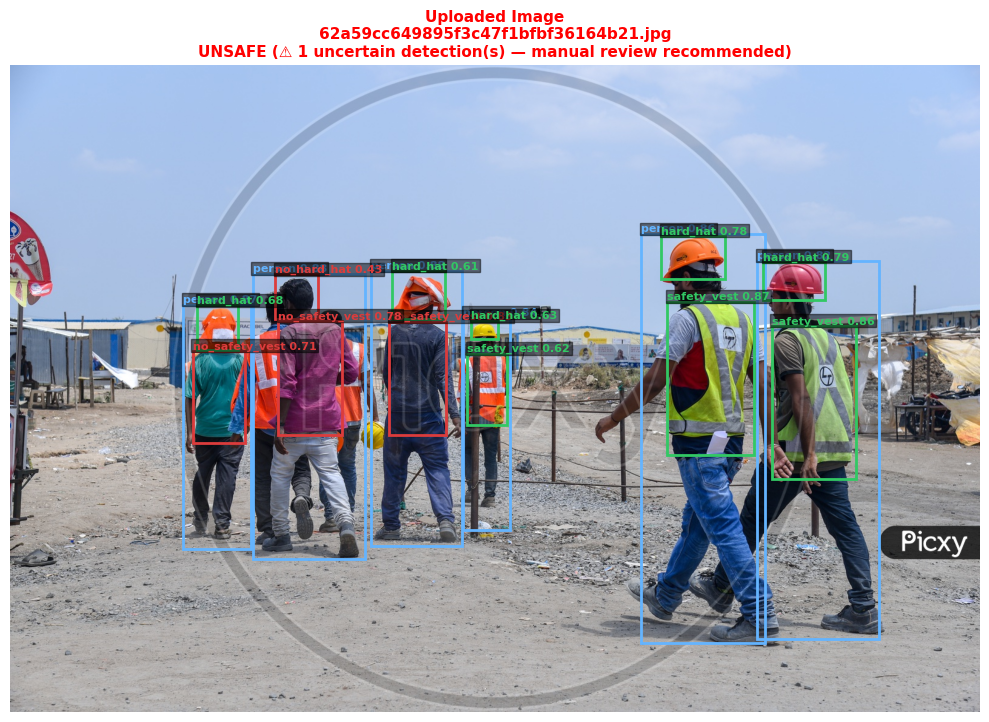

{
  "image": "62a59cc649895f3c47f1bfbf36164b21.jpg",
  "verdict": "UNSAFE (\u26a0 1 uncertain detection(s) \u2014 manual review recommended)",
  "workers_total": 6,
  "compliant": 3,
  "violations": 3,
  "workers": [
    {
      "id": 1,
      "status": "VIOLATION",
      "violations": [
        "Missing safety vest"
      ],
      "confidence": 0.775,
      "uncertain": false
    },
    {
      "id": 2,
      "status": "VIOLATION",
      "violations": [
        "Missing hard hat",
        "Missing safety vest"
      ],
      "confidence": 0.694,
      "uncertain": true
    },
    {
      "id": 3,
      "status": "VIOLATION",
      "violations": [
        "Missing safety vest"
      ],
      "confidence": 0.755,
      "uncertain": false
    },
    {
      "id": 4,
      "status": "COMPLIANT",
      "violations": [],
      "confidence": 0.836,
      "uncertain": false
    },
    {
      "id": 5,
      "status": "COMPLIANT",
      "violations": [],
      "confidence": 0.696,
      "uncer

In [11]:
# Upload and test a custom image
from google.colab import files
import cv2
import json
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path

uploaded = files.upload()

if len(uploaded) == 0:
    print("No image uploaded.")
else:
    img_path = list(uploaded.keys())[0]

    COLORS = {
        'person'         : (100, 180, 255),
        'hard_hat'       : (50,  200, 100),
        'safety_vest'    : (50,  200, 100),
        'no_hard_hat'    : (220,  60,  60),
        'no_safety_vest' : (220,  60,  60),
    }

    preds = best_model.predict(img_path, conf=CONF_THRESH, verbose=False)[0]
    img   = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    ih, iw = img.shape[:2]

    detections = []

    fig, ax = plt.subplots(figsize=(10, 8))

    for box in preds.boxes:
        cls_name = preds.names[int(box.cls)]
        conf     = float(box.conf)
        x1, y1, x2, y2 = box.xyxy[0].tolist()

        detections.append(Detection(
            cls=cls_name,
            conf=conf,
            box=[x1/iw, y1/ih, x2/iw, y2/ih]
        ))

        color = [c/255 for c in COLORS.get(cls_name, (180, 180, 180))]
        rect = patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)

        ax.text(
            x1, max(y1 - 4, 8),
            f'{cls_name} {conf:.2f}',
            color=color,
            fontsize=8,
            fontweight='bold',
            bbox=dict(facecolor='black', alpha=0.5, pad=1)
        )

    reports = associate_ppe_to_workers(detections)
    report  = generate_violation_report(img_path, reports)

    verdict = report['verdict']
    title_color = 'green' if verdict.startswith('SAFE') else 'red'

    ax.imshow(img)
    ax.set_title(
        f'Uploaded Image\n{Path(img_path).name}\n{verdict}',
        fontsize=11,
        color=title_color,
        fontweight='bold'
    )
    ax.axis('off')

    plt.tight_layout()
    plt.show()

    print(json.dumps(report, indent=2))

## 8. Save & Export

In [6]:
# Export to ONNX for deployment
best_model.export(format='onnx', imgsz=640, simplify=True)
print('Exported to ONNX.')

# Download weights to local machine
from google.colab import files
files.download('/content/drive/MyDrive/construction_safety_run1/yolov8m_run1/weights/best.pt')
print('Downloads triggered.')

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 93 layers, 25,842,655 parameters, 0 gradients, 78.7 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/construction_safety_run1/yolov8m_run1/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 9, 8400) (49.6 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 338ms
Prepared 4 packages in 1.59s
Installed 4 packages in 503ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime==1.24.4
 + onnxslim==0.1.90

requirements: AutoUpdate success ✅ 3.1s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloads triggered.


## 9. Summary

| Item | Location |
|---|---|
| Best weights | `construction_safety/yolov8m_run1/weights/best.pt` |
| ONNX export | `construction_safety/yolov8m_run1/weights/best.onnx` |
| Training curves | `training_curves.png` |
| Per-class metrics | `per_class_metrics.png` |
| Inference results | `inference_results.png` |
| Confusion matrix | `construction_safety/yolov8m_run1/confusion_matrix.png` |

**Next steps:**
- Review per-class AP — if `safety_vest` is still weak, add more augmented samples
- Need to tune `CONF_THRESH` and `UNCERTAINTY_THRESH` in the inference section based the precision/recall tradeoff needs
